In [7]:
#Импортируем основные библиотеки для работы с датасетом.
import numpy as np
import pandas as pd
from sklearn.datasets import *
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [8]:
#Загружаем необходимый набор данных.
iris = load_iris()

In [11]:
#Преобразуем в pandas DataFrame.
data = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])

In [14]:
#Проверяем датасет на наличие пропусков.
data.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [15]:
#Пропусков не обнаружено. Выведем первые 5 строк датасета.
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

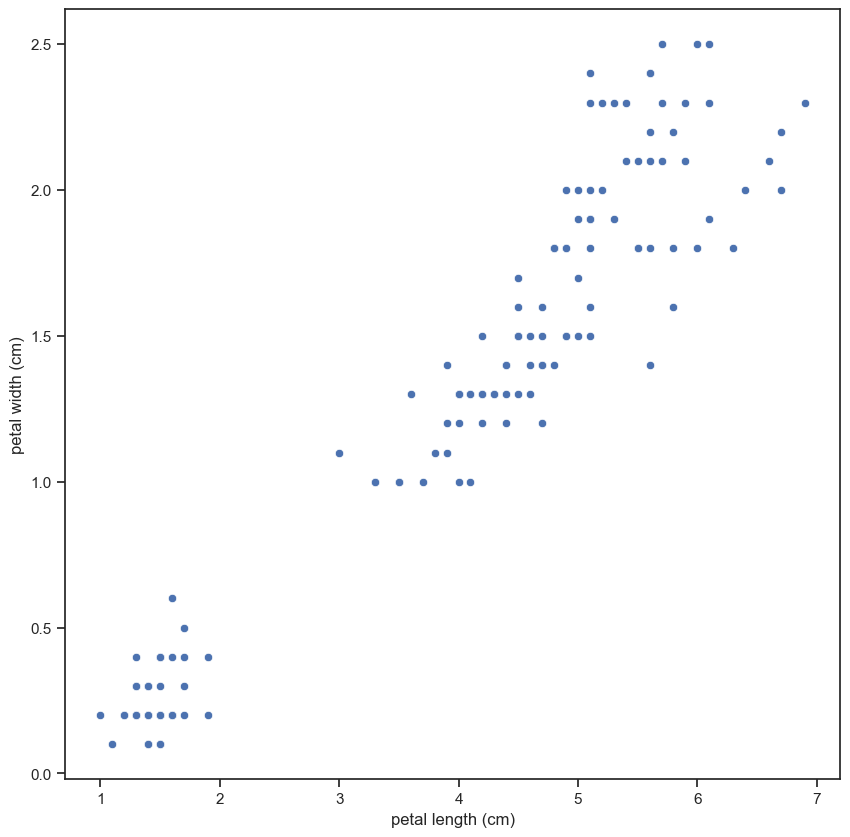

In [20]:
#Построим диаграмму рассеяния для двух колонок petal length и petal width и посмотрим, есть ли между ними зависимость.
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='petal length (cm)', y='petal width (cm)', data=data)

По диаграмме мы можем увидеть, что между выбранными полями присутствует линейная зависимость.

C:\Users\yaros\AppData\Local\Temp\ipykernel_20184\4003487189.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['sepal width (cm)'])


<Axes: xlabel='sepal width (cm)', ylabel='Density'>

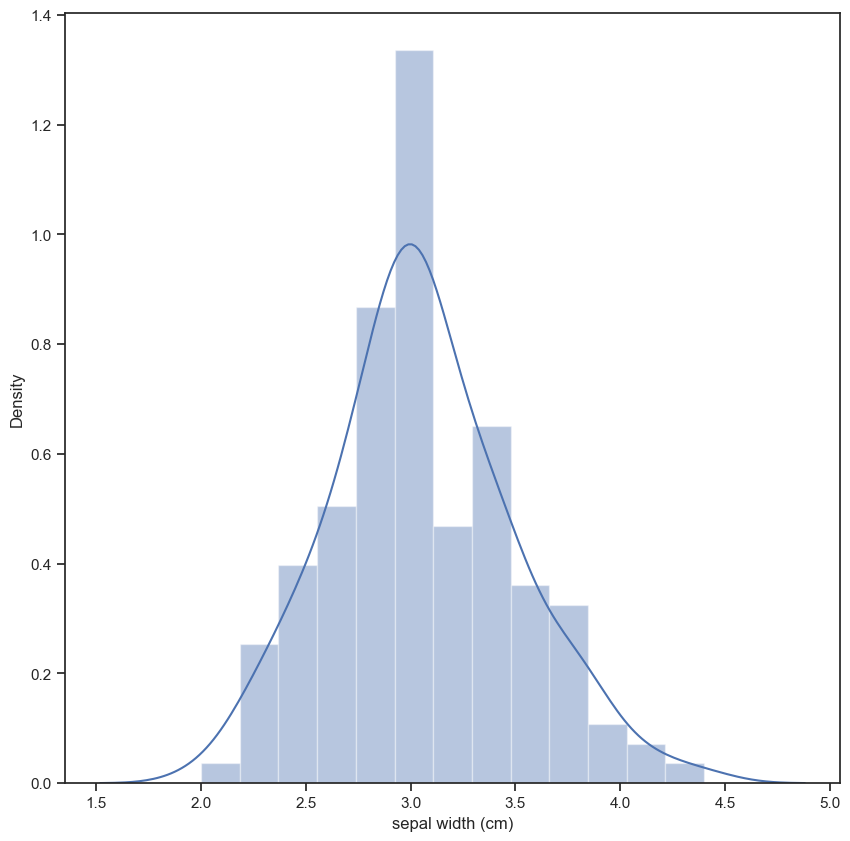

In [26]:
#Построим гистограмму для поля sepal width (cm).
fig, ax = plt.subplots(figsize=(10,10)) 
sns.distplot(data['sepal width (cm)'])

Как видно из гистограммы, чаще всего параметр sepal width принимает значения в диапазоне от 2,5 до 3,5.

<Axes: xlabel='target', ylabel='sepal length (cm)'>

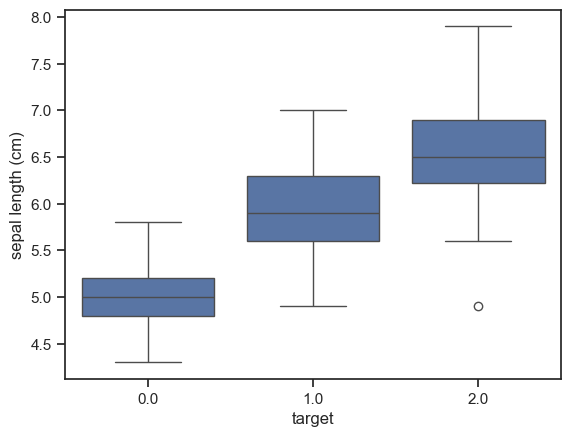

In [28]:
#Посмотрим распределение параметра sepal length сгруппированные по target.
sns.boxplot(x='target', y='sepal length (cm)', data=data)

По построенной диаграмме мы можем посмотреть распределение данных по квартилям, медианы, минимумы и максимумы, а также выбросы данных для поля sepal length, сгруппированных по полю target

In [29]:
#Узнаем, есть ли корреляция между признаками
data.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


Как видно из матрицы, больше всего коррелируют petal width и petal length (0,96).
В их зависимости мы уже могли убедиться на примере диаграммы рассеяния, построенной ранее.